In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/processed/TCS_features.csv")

print(df.head())

         Date       Close        High         Low        Open   Volume  \
0  2014-03-12  837.418457  841.376085  827.255490  827.255490  1669788   
1  2014-03-13  825.929810  846.082854  821.050059  825.353459  2019884   
2  2014-03-14  822.087830  830.137513  816.228261  822.644950  2161246   
3  2014-03-18  815.344177  826.794364  808.524027  820.531334  2565842   
4  2014-03-19  783.606506  797.285222  773.481954  797.285222  8652662   

       SMA_20      SMA_50      EMA_20        RSI      MACD  MACD_signal  \
0  842.083096  850.499503  844.111408  47.413963 -0.413151     1.050955   
1  842.930334  850.500116  842.379827  44.749343 -1.808123     0.479140   
2  843.041763  850.318805  840.447256  41.124534 -3.186927    -0.254074   
3  842.159937  849.579171  838.056486  42.287649 -4.768823    -1.157023   
4  839.739255  848.071305  832.870774  32.776509 -8.485635    -2.622746   

   Daily_Return  Target  
0      0.012920       0  
1     -0.013719       0  
2     -0.004652       0  


In [3]:
features = [
    'Close',
    'SMA_20',
    'SMA_50',
    'EMA_20',
    'RSI',
    'MACD',
    'Daily_Return'
]

data = df[features]

print(data.head())

        Close      SMA_20      SMA_50      EMA_20        RSI      MACD  \
0  837.418457  842.083096  850.499503  844.111408  47.413963 -0.413151   
1  825.929810  842.930334  850.500116  842.379827  44.749343 -1.808123   
2  822.087830  843.041763  850.318805  840.447256  41.124534 -3.186927   
3  815.344177  842.159937  849.579171  838.056486  42.287649 -4.768823   
4  783.606506  839.739255  848.071305  832.870774  32.776509 -8.485635   

   Daily_Return  
0      0.012920  
1     -0.013719  
2     -0.004652  
3     -0.008203  
4     -0.038925  


In [4]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)

(2416, 7)


In [5]:
sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i][0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2386, 30, 7)
y shape: (2386,)


In [6]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1908, 30, 7)
X_test: (478, 30, 7)
y_train: (1908,)
y_test: (478,)


In [7]:
model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(units=64))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

c:\Users\vedan\Stock-Market-Predictor\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0060 - val_loss: 0.0018
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0019 - val_loss: 0.0038
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0015 - val_loss: 8.6134e-04
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0015 - val_loss: 7.6548e-04
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0014 - val_loss: 8.3724e-04
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0015 - val_loss: 0.0036
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0012 - val_loss: 6.4361e-04
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/

In [9]:
predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
RMSE: 0.028394801457722964


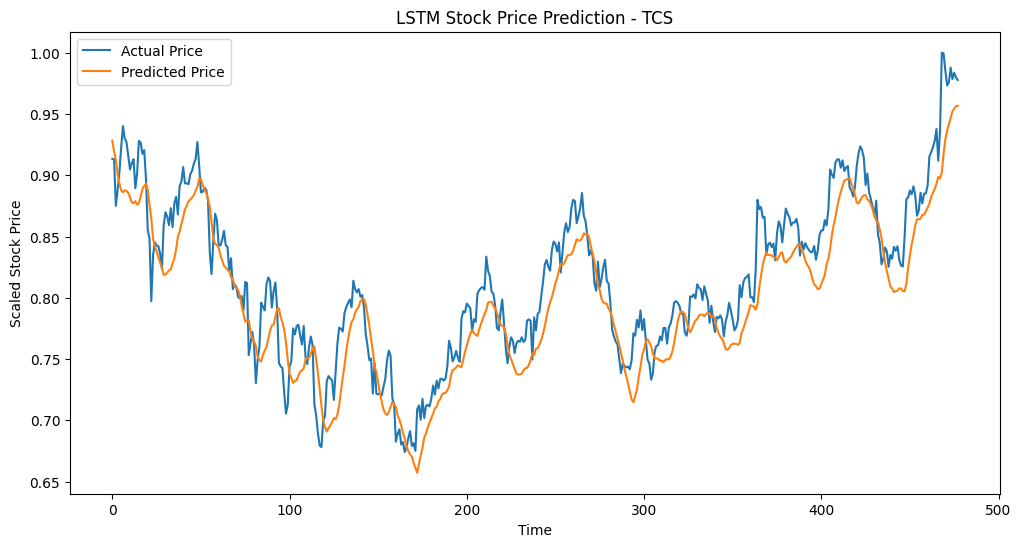

In [10]:
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual Price')
plt.plot(predictions, label='Predicted Price')

plt.title("LSTM Stock Price Prediction - TCS")
plt.xlabel("Time")
plt.ylabel("Scaled Stock Price")

plt.legend()

plt.show()

In [11]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("LSTM RMSE:", rmse)

LSTM RMSE: 0.028394801457722964
